In [6]:
# Packages

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from scipy.stats import norm #Normal PDF and CDF
from numpy.random import normal # normal random variable

## Black-Scholes Equation

The Black-Scholes theorem assume that the stock price follows a geometric Brownian motion, given by,
\begin{align}
dS = \mu S dt + \sigma S dz
\end{align}
where $\mu$ and $\sigma$ are the mean growth rate and volatility, respectively, and $dz$ is the Wiener process. Let's $F(S,t)$ be the price of a derivative on the stock at time $t$ and for stock price $S$. Then according to Ito lemma, derivative price then changes as,
\begin{align*}
dF = \left[\frac{\partial F}{\partial t}+ \mu S\frac{\partial F}{\partial S} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2}\right]dt + \sigma S\frac{\partial F}{\partial S} dz
\end{align*}
We can see that the derivative is also a stochastic process with same underlying Wiener process. We can then show that the *risk-neutral* price of the derivative can be obtained by assuming that the stock and the derivative both grows at the risk-free interest rate $r$, i.e.
\begin{align*}
\frac{\partial F}{\partial t}+ r S\frac{\partial F}{\partial S} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2} = rF
\end{align*}
where we have replaced $\mu$ with $r$ and equated the $dt$ coefficient of the $dF$ with the $rF$. This is the **Black-Scholes differential equation**.

The equation can be obtained by creating a self-financing portfolio, using cash-account and stock, which reproduces the payoff of the derivative. Let the portfolio, at time $t$, consist of $x(t)$ amount in cash and $y(t)$ amount of stock. The value of this portfolio is given by,
\begin{align*}
P(t) = x(t) B(t) + y(t)S(t)
\end{align*}
where $B(t)=e^{rt}$ tracks the change in cash-account due to the interest rate. The change in the value of the portfolio is given by,
\begin{align*}
dP(t) = dx(t) B(t) + x(t) dB(t) + dy(t)S(t) + y(t)dS(t).
\end{align*}
Since this portfolio is self-financing, i.e. the changes in value is only due to change in stock-price and interest-rates, not because we inject to or withdraw from funds externally, we must have $ dx(t) B(t) = -dy(t)S(t)$ (funds are simply rearranged between stock and cash-account).
\begin{align*}
dP(t) &= x(t) dB(t) + y(t)dS(t) \\
dP(t) &= x(t) r B(t) dt + y(t)[\mu S dt + \sigma S dz] \\
\end{align*}
Here we have used the fact that the $B(t)$ grews exponentially at the risk-free interest rate and that stock-price follows geometric Brownian motion.

Since the portfolio should be replicating the derivative price, we require, 
\begin{align*}
\frac{\partial F}{\partial t}+ \mu S\frac{\partial F}{\partial S} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2}  &= x(t) r B(t)  + y(t)\mu S  \\
\sigma S\frac{\partial F}{\partial S}  &= y(t) \sigma S \\
\end{align*}
Here we have equated the deterministic and stochastic parts of $dF$ and $dP$. From using the results from the second equation, ${\partial F}/{\partial S}  = y(t)$ from above, in the first one, we arrive at
\begin{align*}
\frac{\partial F}{\partial t}+ \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2}  &= r x(t) B(t) = r\left[F-S(t) \frac{\partial F}{\partial S} \right]\\
\end{align*}
where we have used $P(t)=F(t)$. The above equation is simple the Black-Scholes equation.

The fact that $\mu$ does not play a role in the price of the system is simple a consequence of the risk-neutral pricing strategy. The price at time $t$ and stock price $S$ can be found by solving the Black-Scholes equation. The price at the maturity of the derivative is simply the payoff, for example $F(S,T)= \max (S-K,0)$ for call options, with maturity $T$ and strike $T$. This is the boundary condition to be applied while solving the equation.

# Dividend paying stock

The Black-Scholes equation is modified if the stock pays dividend. For a dividend rate $c$ that is assumed to paid continually, the self-financing portfolio value changes as,
\begin{align*}
dP(t) =  x(t) dB(t)+ y(t)[\tilde \mu S dt + \sigma S dz] +  y(t)cSdt.
\end{align*}
The last term is the dividend payment. We also used $\tilde\mu = \mu-c$ to indicate that the stock-price reduces as the dividend is payed (just for the sake of consistency). For replicating the derivative value, we need,
\begin{align*}
\frac{\partial F}{\partial t} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2} + (r-c)S \frac{\partial F}{\partial S}  = rF
\end{align*}


## Finite Difference method for solving Black-Scholes equations

In this work, we use finite differences method to numerically find solution to the Black-Scholes equation for European call and put options. In finite-differences, we look at the discretized version of the differential equation, which is solved algebraically. The discretized version of the derivatives are given as,
\begin{align*}
\partial_t F(S_i,t_j) &\approx \frac{F(S_{i},t_{j+1})-F(S_{i},t_j)}{\Delta t} \\
\partial_S F(S_i,t_j) &\approx \frac{F(S_{i+1},t_j)-F(S_{i},t_j)}{\Delta S}  \\
\partial_{S,S} F(S_i,t_j) &\approx \frac{F(S_{i+1},t_j)-2F(S_{i},t_j)+F(S_{i-1},t_j)}{\Delta S^2} 
\end{align*}

From the Black-Scholes equation, we have,
\begin{align*}
\partial_t F(S_i,t_j) = rF - r S\partial_S F(S_i,t_j) - \frac{1}{2}\sigma^2 S^2  \partial_{S,S} F(S_i,t_j)
\end{align*}
From the approximated form provided above, we can write,
\begin{align*}
F(S_{i},t_{j-1}) =  F(S_{i},t_{j}) - \Delta t \left[rF(S_i,t_j) - r S\partial_S F(S_i,t_j) - \frac{1}{2}\sigma^2 S^2  \partial_{S,S} F(S_i,t_j)\right]
\end{align*}
Since the boundary conditions are known at $t=T$, the price is solved backwards in time iteratively. 

In [ ]:

# finite differences calculation of 
# derivative prices under Black-Scholes equation
# Input: Option payoff as a function of stock price
# 
def FiniteDiff_Barrier(Smax,dS,dt,Payoff_func, B, T):
    
    # Defining grids
    # The array for stock goes from B+dS to S_max as at S=B, F=0
    S_grid = np.arange(B+dS,Smax,dS) 
    t_grid = np.arange(0,T+dt,dt)
    print(S_grid[-1])
    # Number of points
    nS = len(S_grid)
    nt = len(t_grid)
    #alpha = dt/dS**2 # Small parameter
    #print("alpha=",alpha)

    # Stores option price at various t and S
    F_grid = np.zeros([nt,nS]) 

    # Boundary Values (at t=T)
    # price at t=T is the option payoff
    F_grid[-1] = Payoff_func(S_grid)
    
    # Calculating price backwards in time
    #start_time = time.time()
    for i in range(nt-1):

        # calculating derivatives
        dF_grid = np.diff(F_grid[nt-i-1],prepend=0.0)/dS #prepend ensures that the boundary condition
        ddF_grid = np.diff(dF_grid,append=1.0)/dS

        # Finite difference sequence: vector form
        G1 = 0.5*ddF_grid*(sigma*S_grid)**2
        G2 = (r-c)*S_grid*dF_grid
        G3 = (r-c)*F_grid[nt-i-1]
        F_grid[nt-i-2] = F_grid[nt-i-1] + dt* (G1+G2-G3)
    
    #print("--- %s seconds ---" % (time.time() - start_time))
    return F_grid

## Black-Scholes Formula

The Black-Scholes theorem assumes that the stock price follows a geometric brownian motion. The fair price of a european call option on the stock at time $t$ is given by,
$$C(S,t) = S\Phi(d_1) -K\Phi(d_2)\exp[-r(T-t)],$$
where $S$ is the stock price at $t$, $K$ is the strike price, and $T$ is the expiration time. We also have the risk-free interest rate $r$, 
$$ d_1=\frac{\log(S/K)+(r+\sigma^2/2)(T-t)}{\sigma\sqrt{T-t}},$$
and 
$$d_2 = d_1-\sigma\sqrt{T-t}$$
Here, $\sigma$ is the volatility of the stock price

The put price $ P(S,t) $ can be obtained from the call price using put-call parity of european options
$$ C(S,t) + K \exp[-r(T-t)] = P(S,t) + S_t $$



In [ ]:

#---------------------------------------
# Numerical option pricing using explicit 
# finite differences method
# K : Strike price
# r : Risk-free interest rates
# c : Dividend rate
# Smax, dS, T, dt: grid specs on stock price (S) and time (T)
# Opt_type : "Call" or "Put"
def FiniteDiff_European(Opt_type,K,sigma,r,c,Smax,dS,T,dt ):
    
    # Defining grids
    S_grid = np.arange(0,Smax,dS) # stock price
    t_grid = np.arange(0,T+dt,dt) # time 

    # Number of points
    nS, nt = len(S_grid), len(t_grid)

    # Stores option price at various t and S
    F_grid = np.zeros([nt,nS]) 

    # Boundary Values (at t=T)
    if Opt_type == "Call":
        F_grid[nt-1] =  np.maximum(0,S_grid-K)
    if Opt_type == "Put":
        F_grid[nt-1] = np.maximum(np.zeros(nS),K-S_grid) 
    
    # Calculating price backwards in time
    #start_time = time.time()
    for i in range(nt-1):

        # calculating derivatives
        if Opt_type == "Call":
            dF_grid = np.diff(F_grid[nt-i-1],prepend=0.0)/dS # first deriv. 
            ddF_grid = np.diff(dF_grid,append=1.0)/dS # second deriv.
        if Opt_type == "Put":
            dF_grid = np.diff(F_grid[nt-i-1],append=0.0)/dS # first deriv.
            ddF_grid = np.diff(dF_grid,prepend=-1.0)/dS # second deriv.
            #ddF_grid[-1]=0.0
        #if i<3:
        #    print(dF_grid,ddF_grid,i,F_grid[nt-i-1])
        # Finite difference sequence: vector form
        G1 = 0.5*ddF_grid*(sigma*S_grid)**2
        G2 = (r-c)*S_grid*dF_grid
        G3 = (r-c)*F_grid[nt-i-1]
        F_grid[nt-i-2] = F_grid[nt-i-1] + dt* (G1+G2-G3)
    
    #print("--- %s seconds ---" % (time.time() - start_time))
    return S_grid, t_grid , F_grid
    
# ------------------------------------
# Analytical price of European options
def OptionPriceAnalytical(Opt_type,K,sigma,r,c,St_arr,T,t):
    t_period = T-t # Time to maturity
    d1 = (np.log(St_arr/K)+(r-c+0.5*sigma**2)*t_period)/(sigma*np.sqrt(t_period))
    d2 = d1-(sigma*np.sqrt(t_period))
    if Opt_type == "Call":
        return np.exp(-c*t_period)*St_arr*norm.cdf(d1) - np.exp(-r*t_period)*K*norm.cdf(d2)
    if Opt_type == "Put":
        return -np.exp(-c*t_period)*St_arr*norm.cdf(-d1) + np.exp(-r*t_period)*K*norm.cdf(-d2)



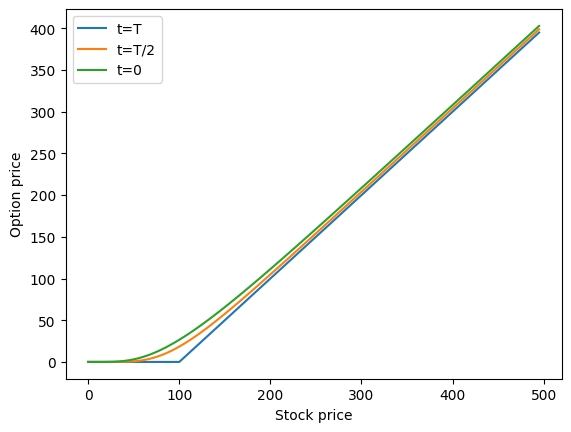

In [ ]:

# -----------------------
# Parameters
# Option parameters
r = 0.1 #interest rate
K = 100 # strike
S0 = 100 # Current price 
sigma = 0.6 # volatility
c = 0.02 # dividend yield
T = 1 # Expiry time (years)

# Grid parameters
Smax = 500 # Max stock price
dS = 5 # grid size (stock price grio)
dt = 0.0001 # grid size (time grid)

#----------------------------
# Solving for derivative price
S_grid, tgrid, Price_grid_call = FiniteDiff_European("Call",K,sigma,r,c,Smax,dS,T,dt )
S_grid, tgrid, Price_grid_put = FiniteDiff_European("Put",K,sigma,r,c,Smax,dS,T,dt )

t1, t2, t3 = T, T/2, 0 #Choosing three times
n1, n2, n3 = int(t1/dt), int(t2/dt), int(t3/dt) #index


/var/folders/53/85zwmkmn6dv27k0hq0vkmqh80000gn/T/ipykernel_78662/1974902991.py:54: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(St_arr/K)+(r-c+0.5*sigma**2)*t_period)/(sigma*np.sqrt(t_period))


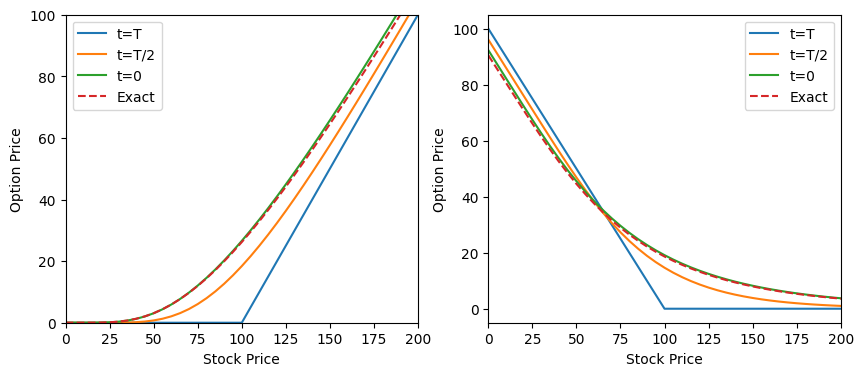

In [66]:
# Exact prices at t=0 from formula
Price_grid_exc_put = OptionPriceAnalytical("Put",100,sigma,r,c,S_grid,T,0)
Price_grid_exc_call = OptionPriceAnalytical("Call",100,sigma,r,c,S_grid,T,0)

fig, ax = plt.subplots(1,2, figsize=(10, 4))

ax[0].plot(S_grid,Price_grid_call[n1], label="t=T")
ax[0].plot(S_grid,Price_grid_call[n2], label="t=T/2")
ax[0].plot(S_grid,Price_grid_call[n3], label="t=0")
ax[0].plot(S_grid,Price_grid_exc_call, '--', label="Exact")
ax[0].set_xlim(0,200)
ax[0].set_ylim(0,100)
ax[0].set_xlabel("Stock Price")
ax[0].set_ylabel("Option Price")
ax[0].legend()

ax[1].plot(S_grid,Price_grid_put[n1], label="t=T")
ax[1].plot(S_grid,Price_grid_put[n2], label="t=T/2")
ax[1].plot(S_grid,Price_grid_put[n3], label="t=0")
ax[1].plot(S_grid,Price_grid_exc_put, '--', label="Exact")
ax[1].set_xlim(0,200)
ax[1].set_xlabel("Stock Price")
ax[1].set_ylabel("Option Price")
ax[1].legend()